In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split


df = pd.read_csv("../data/raw/clinvar_clnsig_annotated.csv")
print(df.shape)
print(df.columns.tolist())
print(df["CLNSIG"].value_counts(dropna=False).head(30))

(60480, 47)
['CHROM', 'POS', 'REF', 'ALT', 'AF_ESP', 'AF_EXAC', 'AF_TGP', 'CLNDISDB', 'CLNDISDBINCL', 'CLNDN', 'CLNDNINCL', 'CLNHGVS', 'CLNSIG', 'CLNSIGINCL', 'CLNVC', 'CLNVI', 'MC', 'ORIGIN', 'SSR', 'CLASS', 'Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'DISTANCE', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']
CLNSIG
Uncertain_significance                                       20358
Likely_benign                                                13549
Benign                                                        8272
Pathogenic                                                    7073
Benign/Likely_benign                                          4824
Likely_pathogenic                                             2432
Conflicting_interpretations_of_path

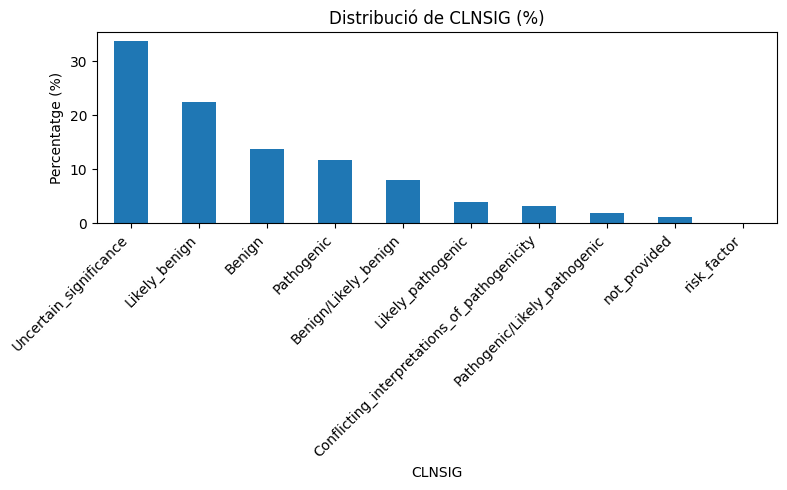

In [2]:

counts = df["CLNSIG"].value_counts(dropna=False)
percent = (counts / counts.sum()) * 100
top_percent = percent.head(10)

plt.figure(figsize=(8,5))
top_percent.plot(kind="bar")

plt.title("Distribució de CLNSIG (%)")
plt.ylabel("Percentatge (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Creació Classes

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Valors que pertanyen a cada classe
benign_values = [
    "Benign", "Likely_benign", "Benign/Likely_benign",
    "Benign,_risk_factor", "Benign,_other", "Benign,_association",
    "Benign/Likely_benign,_risk_factor", "Benign/Likely_benign,_other",
    "Likely_benign,_risk_factor", "Likely_benign,_association"
]
vus_values = [
    "Uncertain_significance"
]
pathogenic_values = [
    "Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic",
    "Pathogenic,_risk_factor", "Pathogenic/Likely_pathogenic,_risk_factor",
    "Pathogenic,_association"
]

clnsig_map = (
    {v: 0 for v in benign_values} |
    {v: 1 for v in vus_values}    |
    {v: 2 for v in pathogenic_values}
)

# Filtrar i crear target (descartem Conflicting, not_provided, etc.)
df_multi = df[df["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi["CLNSIG_target"] = df_multi["CLNSIG"].map(clnsig_map)

# Comprovació distribució
print(df_multi["CLNSIG_target"].value_counts())
print(df_multi["CLNSIG_target"].value_counts(normalize=True).round(3))

# Columnes a eliminar: target, CLASS antiga, i les que revelarien el resultat
cols_to_drop = ["CLNSIG", "CLNSIG_target", "CLASS"]

for col in ["CLNSIGCONF", "CLNREVSTAT"]:
    if col in df_multi.columns:
        cols_to_drop.append(col)
        print(f"⚠️  Eliminant columna que revela target: {col}")
    else:
        print(f"✓ {col} no estava al dataset")

X = df_multi.drop(columns=cols_to_drop)
y = df_multi["CLNSIG_target"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print(f"\nX_train_val: {X_train_val.shape}")
print(f"X_test:      {X_test.shape}")

CLNSIG_target
0    26692
1    20358
2    10641
Name: count, dtype: int64
CLNSIG_target
0    0.463
1    0.353
2    0.184
Name: proportion, dtype: float64
✓ CLNSIGCONF no estava al dataset
✓ CLNREVSTAT no estava al dataset

X_train_val: (51921, 45)
X_test:      (5770, 45)


In [4]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_multi = df[df["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi["CLNSIG_target"] = df_multi["CLNSIG"].map(clnsig_map)


X = df_multi.drop(columns=["CLNSIG", "CLNSIG_target", "CLASS"])
y = df_multi["CLNSIG_target"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# ── Preprocessat ─────────────────────────────────────────────────────────────
cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]
X_train_val = X_train_val.drop(columns=cols_high_missing, errors="ignore")
X_test      = X_test.drop(columns=cols_high_missing, errors="ignore")

cols_all_missing = X_train_val.columns[X_train_val.isnull().mean() == 1.0].tolist()
if cols_all_missing:
    X_train_val = X_train_val.drop(columns=cols_all_missing)
    X_test      = X_test.drop(columns=cols_all_missing, errors="ignore")

num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

print("X_train_val shape:", X_train_val.shape)
print("X_test shape:", X_test.shape)

X_train_val shape: (51921, 36)
X_test shape: (5770, 36)


## Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits
── DECISION TREE ──────────────────────────────
Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Millor CV F1 macro: 0.887493705877039

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94      2670
         VUS       0.86      0.86      0.86      2036
  Pathogenic       0.86      0.85      0.86      1064

    accuracy                           0.89      5770
   macro avg       0.88      0.88      0.88      5770
weighted avg       0.89      0.89      0.89      5770

F1 macro al test: 0.8839536159903304


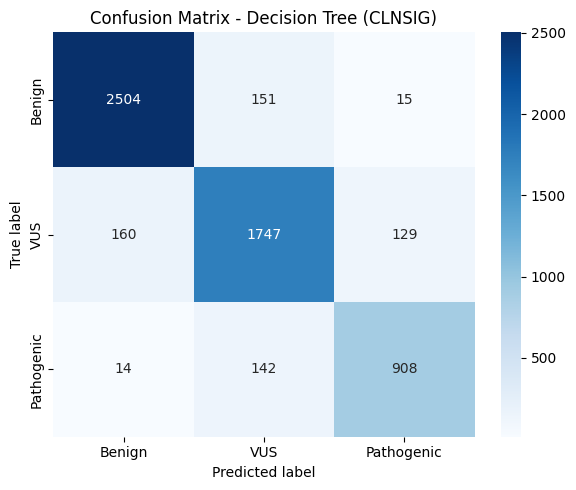

In [5]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix
)
 
# Noms de les classes per als plots
CLASS_NAMES = ["Benign", "VUS", "Pathogenic"]
 
# ── Funció auxiliar per pintar la confusion matrix ──────────────────────────
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()
 
 
# ════════════════════════════════════════════════════════════════════════════
# DECISION TREE
# ════════════════════════════════════════════════════════════════════════════
dt = DecisionTreeClassifier(random_state=42)
 
pipeline_dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt)
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]   # important pel desbalanceig Pathogenic
}
 
grid_dt = GridSearchCV(
    pipeline_dt,
    param_grid=param_grid,
    scoring="f1_macro",     # macro perquè tenim 3 classes no equilibrades
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
 
grid_dt.fit(X_train_val, y_train_val)
print("── DECISION TREE ──────────────────────────────")
print("Millors paràmetres:", grid_dt.best_params_)
print("Millor CV F1 macro:", grid_dt.best_score_)
 
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
 
print("\nClassification report al test:")
print(classification_report(y_test, y_pred_dt, target_names=CLASS_NAMES))
print("F1 macro al test:", f1_score(y_test, y_pred_dt, average="macro"))
 
plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_dt),
    "Confusion Matrix - Decision Tree (CLNSIG)"
)
 

## Random Forest

Fitting 5 folds for each of 15 candidates, totalling 75 fits
── RANDOM FOREST ──────────────────────────────
Millors paràmetres: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None, 'model__class_weight': 'balanced'}
Millor CV F1 macro: 0.8991104644756126

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95      2670
         VUS       0.89      0.86      0.88      2036
  Pathogenic       0.90      0.86      0.88      1064

    accuracy                           0.91      5770
   macro avg       0.91      0.90      0.90      5770
weighted avg       0.91      0.91      0.91      5770

F1 macro al test: 0.9024084786181561


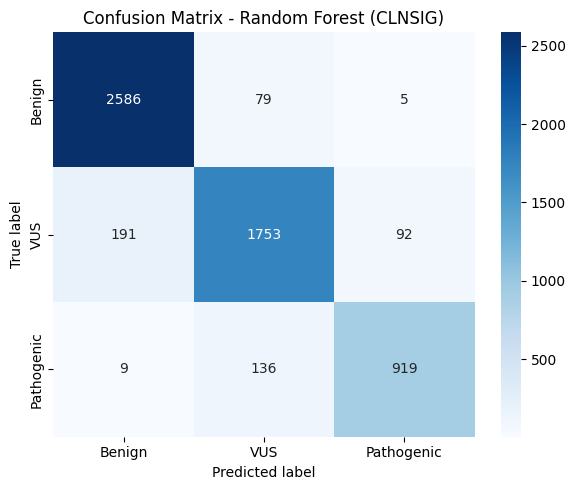

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search_rf.fit(X_train_val, y_train_val)
print("── RANDOM FOREST ──────────────────────────────")
print("Millors paràmetres:", random_search_rf.best_params_)
print("Millor CV F1 macro:", random_search_rf.best_score_)

best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))
print("F1 macro al test:", f1_score(y_test, y_pred_rf, average="macro"))

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_rf),
    "Confusion Matrix - Random Forest (CLNSIG)"
)

## MLP

Fitting 5 folds for each of 20 candidates, totalling 100 fits
── MLP ────────────────────────────────────────
Millors paràmetres: {'model__learning_rate_init': 0.003, 'model__hidden_layer_sizes': (32, 16), 'model__batch_size': 128, 'model__alpha': 0.001, 'model__activation': 'relu'}
Millor CV F1 macro: 0.8711511666374714

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.95      0.87      0.91      2670
         VUS       0.79      0.90      0.84      2036
  Pathogenic       0.90      0.86      0.88      1064

    accuracy                           0.88      5770
   macro avg       0.88      0.88      0.88      5770
weighted avg       0.89      0.88      0.88      5770

F1 macro al test: 0.8770306513375609


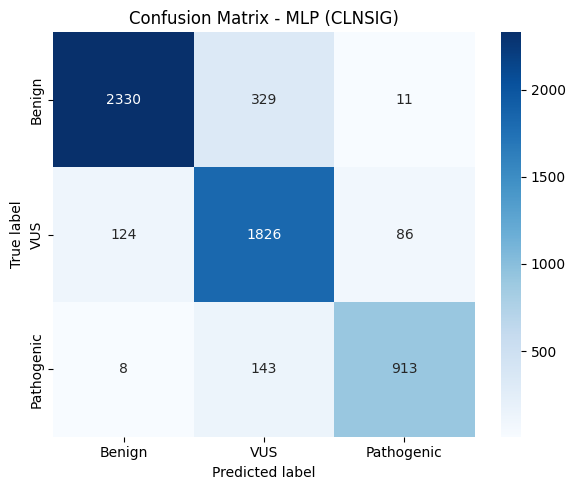

In [7]:
import warnings
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)

mlp = MLPClassifier(
    random_state=42,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

pipeline_mlp = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "model__hidden_layer_sizes": [(32,), (64,), (128,), (32, 16), (64, 32), (128, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-4, 1e-3, 5e-3, 1e-2, 5e-2],
    "model__learning_rate_init": [1e-4, 3e-4, 5e-4, 1e-3, 3e-3],
    "model__batch_size": [64, 128, 256]
}

random_search_mlp = RandomizedSearchCV(
    estimator=pipeline_mlp,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

random_search_mlp.fit(X_train_val, y_train_val)
print("── MLP ────────────────────────────────────────")
print("Millors paràmetres:", random_search_mlp.best_params_)
print("Millor CV F1 macro:", random_search_mlp.best_score_)

best_mlp = random_search_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_mlp, target_names=CLASS_NAMES))
print("F1 macro al test:", f1_score(y_test, y_pred_mlp, average="macro"))

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_mlp),
    "Confusion Matrix - MLP (CLNSIG)"
)


## CLNSIG – Dataset Bàsic (sense anotació VEP)

In [8]:
# ── Crear dataset bàsic (sense columnes VEP) a partir de df annotated ────
vep_cols = [
    "Allele", "Consequence", "IMPACT", "SYMBOL", "Feature_type", "Feature",
    "BIOTYPE", "EXON", "INTRON", "cDNA_position", "CDS_position",
    "Protein_position", "Amino_acids", "Codons", "STRAND", "BAM_EDIT",
    "SIFT", "PolyPhen", "LoFtool", "CADD_PHRED", "CADD_RAW", "BLOSUM62"
]

df_basic = df.drop(columns=[c for c in vep_cols if c in df.columns])
df_basic.to_csv("../data/raw/clinvar_clnsig_basic.csv", index=False)

print("Annotated shape:", df.shape)
print("Basic shape:    ", df_basic.shape)
print("Columnes eliminades:", [c for c in vep_cols if c in df.columns])


Annotated shape: (60480, 47)
Basic shape:     (60480, 25)
Columnes eliminades: ['Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']


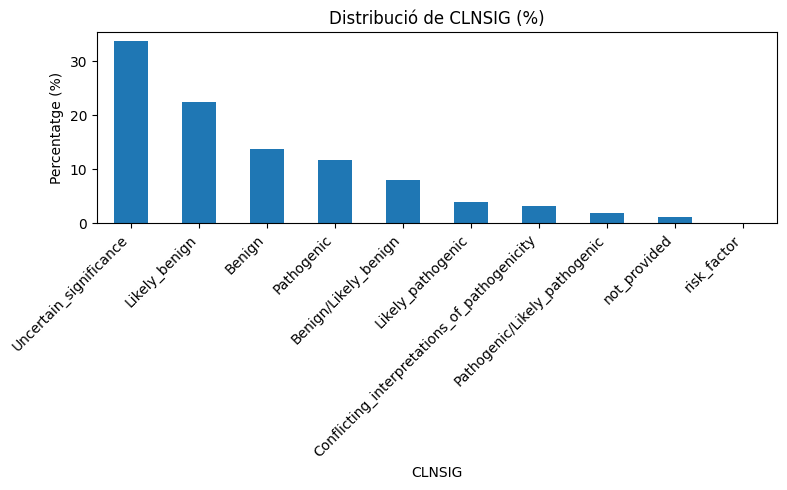

In [9]:

counts = df_basic["CLNSIG"].value_counts(dropna=False)
percent = (counts / counts.sum()) * 100
top_percent = percent.head(10)

plt.figure(figsize=(8,5))
top_percent.plot(kind="bar")

plt.title("Distribució de CLNSIG (%)")
plt.ylabel("Percentatge (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Creació Classes (Bàsic)

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Valors que pertanyen a cada classe
benign_values = [
    "Benign", "Likely_benign", "Benign/Likely_benign",
    "Benign,_risk_factor", "Benign,_other", "Benign,_association",
    "Benign/Likely_benign,_risk_factor", "Benign/Likely_benign,_other",
    "Likely_benign,_risk_factor", "Likely_benign,_association"
]
vus_values = [
    "Uncertain_significance"
]
pathogenic_values = [
    "Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic",
    "Pathogenic,_risk_factor", "Pathogenic/Likely_pathogenic,_risk_factor",
    "Pathogenic,_association"
]

clnsig_map = (
    {v: 0 for v in benign_values} |
    {v: 1 for v in vus_values}    |
    {v: 2 for v in pathogenic_values}
)

# Filtrar i crear target (descartem Conflicting, not_provided, etc.)
df_multi_basic = df_basic[df_basic["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi_basic["CLNSIG_target"] = df_multi_basic["CLNSIG"].map(clnsig_map)

# Comprovació distribució
print(df_multi_basic["CLNSIG_target"].value_counts())
print(df_multi_basic["CLNSIG_target"].value_counts(normalize=True).round(3))

# Columnes a eliminar: target, CLASS antiga, i les que revelarien el resultat
cols_to_drop = ["CLNSIG", "CLNSIG_target", "CLASS"]

for col in ["CLNSIGCONF", "CLNREVSTAT"]:
    if col in df_multi_basic.columns:
        cols_to_drop.append(col)
        print(f"⚠️  Eliminant columna que revela target: {col}")
    else:
        print(f"✓ {col} no estava al dataset")

X = df_multi_basic.drop(columns=cols_to_drop)
y = df_multi_basic["CLNSIG_target"]

X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print(f"\nX_train_val: {X_train_val_basic.shape}")
print(f"X_test_basic:      {X_test_basic.shape}")

CLNSIG_target
0    26692
1    20358
2    10641
Name: count, dtype: int64
CLNSIG_target
0    0.463
1    0.353
2    0.184
Name: proportion, dtype: float64
✓ CLNSIGCONF no estava al dataset
✓ CLNREVSTAT no estava al dataset

X_train_val: (51921, 23)
X_test_basic:      (5770, 23)


In [11]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_multi_basic = df_basic[df_basic["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi_basic["CLNSIG_target"] = df_multi_basic["CLNSIG"].map(clnsig_map)


X = df_multi_basic.drop(columns=["CLNSIG", "CLNSIG_target", "CLASS"])
y = df_multi_basic["CLNSIG_target"]

X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# ── Preprocessat ─────────────────────────────────────────────────────────────
cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]
X_train_val_basic = X_train_val_basic.drop(columns=cols_high_missing, errors="ignore")
X_test_basic      = X_test_basic.drop(columns=cols_high_missing, errors="ignore")

cols_all_missing = X_train_val_basic.columns[X_train_val_basic.isnull().mean() == 1.0].tolist()
if cols_all_missing:
    X_train_val_basic = X_train_val_basic.drop(columns=cols_all_missing)
    X_test_basic      = X_test_basic.drop(columns=cols_all_missing, errors="ignore")

num_cols = X_train_val_basic.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val_basic.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
preprocessor_basic = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

print("X_train_val_basic shape:", X_train_val_basic.shape)
print("X_test_basic shape:", X_test_basic.shape)

X_train_val_basic shape: (51921, 14)
X_test_basic shape: (5770, 14)


## Decision Tree (Bàsic)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
── DECISION TREE ──────────────────────────────
Millors paràmetres: {'model__class_weight': None, 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 20}
Millor CV F1 macro: 0.8705747757020579

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.95      0.94      2670
         VUS       0.83      0.86      0.85      2036
  Pathogenic       0.88      0.78      0.83      1064

    accuracy                           0.88      5770
   macro avg       0.88      0.86      0.87      5770
weighted avg       0.88      0.88      0.88      5770

F1 macro al test: 0.8693716428895804


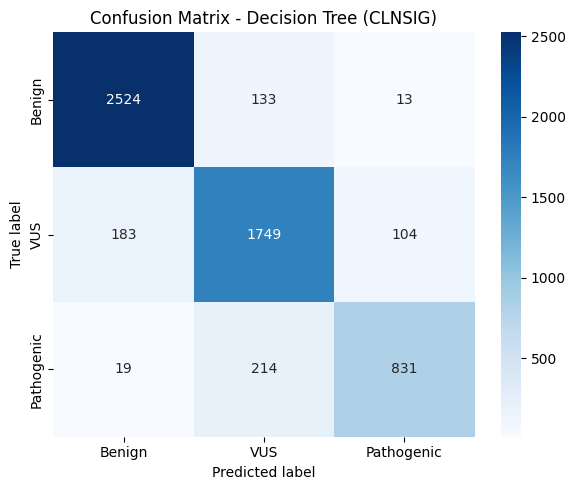

In [12]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix
)
 
# Noms de les classes per als plots
CLASS_NAMES = ["Benign", "VUS", "Pathogenic"]
 
# ── Funció auxiliar per pintar la confusion matrix ──────────────────────────
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()
 
 
# ════════════════════════════════════════════════════════════════════════════
# DECISION TREE
# ════════════════════════════════════════════════════════════════════════════
dt = DecisionTreeClassifier(random_state=42)
 
pipeline_dt_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", dt)
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]   # important pel desbalanceig Pathogenic
}
 
grid_dt_basic = GridSearchCV(
    pipeline_dt_basic,
    param_grid=param_grid,
    scoring="f1_macro",     # macro perquè tenim 3 classes no equilibrades
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
 
grid_dt_basic.fit(X_train_val_basic, y_train_val_basic)
print("── DECISION TREE ──────────────────────────────")
print("Millors paràmetres:", grid_dt_basic.best_params_)
print("Millor CV F1 macro:", grid_dt_basic.best_score_)
 
best_dt_basic = grid_dt_basic.best_estimator_
y_pred_dt_basic = best_dt_basic.predict(X_test_basic)
 
print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_dt_basic, target_names=CLASS_NAMES))
print("F1 macro al test:", f1_score(y_test_basic, y_pred_dt_basic, average="macro"))
 
plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_dt_basic),
    "Confusion Matrix - Decision Tree (CLNSIG)"
)
 

## Random Forest (Bàsic)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
── RANDOM FOREST ──────────────────────────────
Millors paràmetres: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None, 'model__class_weight': 'balanced'}
Millor CV F1 macro: 0.8760653901840596

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95      2670
         VUS       0.87      0.85      0.86      2036
  Pathogenic       0.86      0.81      0.83      1064

    accuracy                           0.90      5770
   macro avg       0.88      0.87      0.88      5770
weighted avg       0.89      0.90      0.89      5770

F1 macro al test: 0.8794437237833354


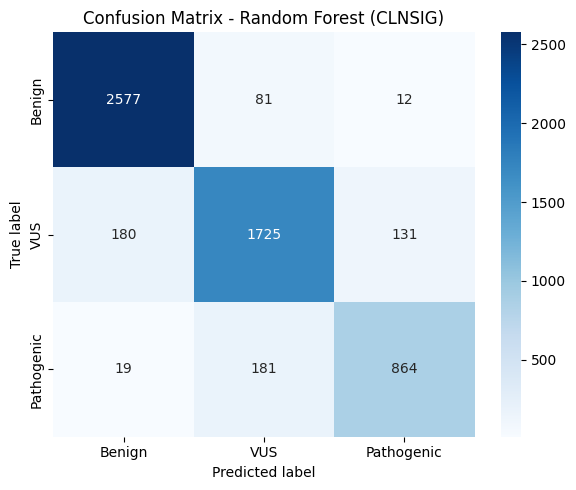

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline_rf_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

random_search_rf_basic = RandomizedSearchCV(
    estimator=pipeline_rf_basic,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search_rf_basic.fit(X_train_val_basic, y_train_val_basic)
print("── RANDOM FOREST ──────────────────────────────")
print("Millors paràmetres:", random_search_rf_basic.best_params_)
print("Millor CV F1 macro:", random_search_rf_basic.best_score_)

best_rf_basic = random_search_rf_basic.best_estimator_
y_pred_rf_basic = best_rf_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_rf_basic, target_names=CLASS_NAMES))
print("F1 macro al test:", f1_score(y_test_basic, y_pred_rf_basic, average="macro"))

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_rf_basic),
    "Confusion Matrix - Random Forest (CLNSIG)"
)

## MLP (Bàsic)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
── MLP ────────────────────────────────────────
Millors paràmetres: {'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (128,), 'model__batch_size': 256, 'model__alpha': 0.0001, 'model__activation': 'relu'}
Millor CV F1 macro: 0.7432657674826212

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.99      0.55      0.71      2670
         VUS       0.58      0.97      0.72      2036
  Pathogenic       0.89      0.71      0.79      1064

    accuracy                           0.73      5770
   macro avg       0.82      0.75      0.74      5770
weighted avg       0.83      0.73      0.73      5770

F1 macro al test: 0.7420671096164781


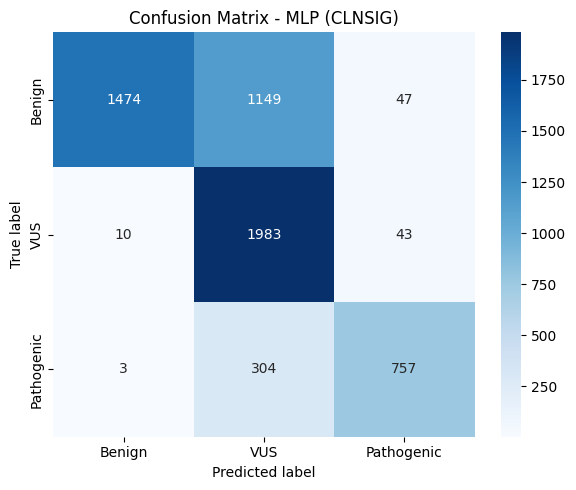

In [14]:
import warnings
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)

mlp = MLPClassifier(
    random_state=42,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

pipeline_mlp_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "model__hidden_layer_sizes": [(32,), (64,), (128,), (32, 16), (64, 32), (128, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-4, 1e-3, 5e-3, 1e-2, 5e-2],
    "model__learning_rate_init": [1e-4, 3e-4, 5e-4, 1e-3, 3e-3],
    "model__batch_size": [64, 128, 256]
}

random_search_mlp_basic = RandomizedSearchCV(
    estimator=pipeline_mlp_basic,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

random_search_mlp_basic.fit(X_train_val_basic, y_train_val_basic)
print("── MLP ────────────────────────────────────────")
print("Millors paràmetres:", random_search_mlp_basic.best_params_)
print("Millor CV F1 macro:", random_search_mlp_basic.best_score_)

best_mlp_basic = random_search_mlp_basic.best_estimator_
y_pred_mlp_basic = best_mlp_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_mlp_basic, target_names=CLASS_NAMES))
print("F1 macro al test:", f1_score(y_test_basic, y_pred_mlp_basic, average="macro"))

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_mlp_basic),
    "Confusion Matrix - MLP (CLNSIG)"
)

## Comparació de Models

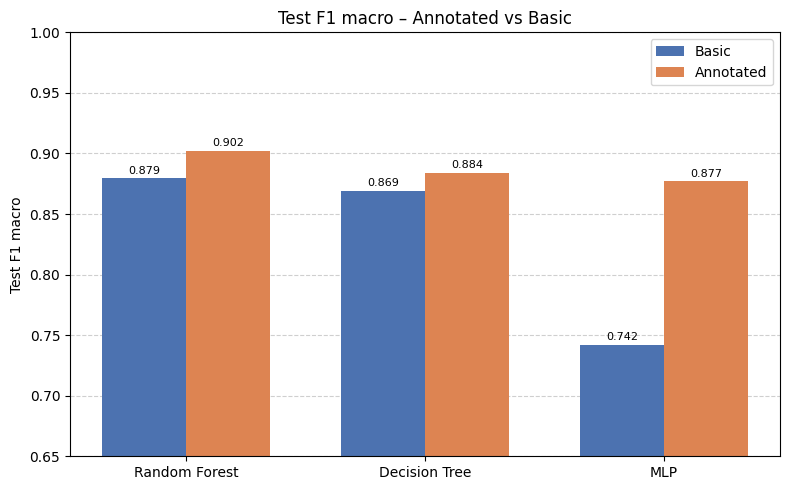

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = [
    ("Decision Tree", "Annotated", grid_dt.best_score_,               y_test,       y_pred_dt),
    ("Random Forest", "Annotated", random_search_rf.best_score_,      y_test,       y_pred_rf),
    ("MLP",           "Annotated", random_search_mlp.best_score_,     y_test,       y_pred_mlp),
    ("Decision Tree", "Basic",     grid_dt_basic.best_score_,         y_test_basic, y_pred_dt_basic),
    ("Random Forest", "Basic",     random_search_rf_basic.best_score_,  y_test_basic, y_pred_rf_basic),
    ("MLP",           "Basic",     random_search_mlp_basic.best_score_, y_test_basic, y_pred_mlp_basic),
]

rows = []
for name, dataset, cv_f1, y_true, y_pred in models:
    rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    rows.append({
        "Model":         name,
        "Dataset":       dataset,
        "CV F1 macro":   round(cv_f1, 4),
        "Test F1 macro": round(rep["macro avg"]["f1-score"], 4),
        "Test Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "F1 Benign":     round(rep["Benign"]["f1-score"], 4),
        "F1 VUS":        round(rep["VUS"]["f1-score"], 4),
        "F1 Pathogenic": round(rep["Pathogenic"]["f1-score"], 4),
    })

df_results = pd.DataFrame(rows)


# Gràfic comparatiu Annotated vs Basic 
model_names = pivot.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, pivot["Basic"],      width, label="Basic",      color="#4C72B0")
ax.bar(x + width/2, pivot["Annotated"],  width, label="Annotated",  color="#DD8452")

for i, (b, a) in enumerate(zip(pivot["Basic"], pivot["Annotated"])):
    ax.text(i - width/2, b + 0.002, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, a + 0.002, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0.65, 1.00)
ax.set_ylabel("Test F1 macro")
ax.set_title("Test F1 macro – Annotated vs Basic")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
